In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import laplace
from IPython.display import HTML

In [3]:
# If you install the package properly, it should be imported directly
from seisrtm.model import ElasticModel
from seisrtm.survey import Survey, Source, Receiver
from seisrtm.propagator import ElasticPropagator
from seisrtm.utils import wavelet, plot_wavefield

## Model the 'Observed' Data

### Parameters for elastic model

In [4]:
# Basic parameters for modeling
ox = 0.0
oz = 0.0
nx = 501
nz = 61
dx = 10.0
dz = 10.0

nt = 4001
dt = 0.001
f0 = 2.0
amp = 1e7

# Set up the true model
vs1 = 1200
vs2 = 2000
vs = np.ones((nz, nx), dtype=np.float32) * vs1
vs[:,250:] = vs2
vp = vs * 1.732
rho = np.power(vp, 0.25) * 310

# Create a elastic model object
model_true = ElasticModel(ox, oz, dx, dz, nx, nz, vp = vp, vs = vs,rho = rho, free_surface=True, nabc=20)
model_true

Earth model with parameters ['vp', 'vs', 'rho']:
  Model vp  :  2078.40 -  3464.00 m/s   , requires_grad = False, constrain bound: None - None
  Model vs  :  1200.00 -  2000.00 m/s   , requires_grad = False, constrain bound: None - None
  Model rho :  2093.12 -  2378.24 kg/m^3, requires_grad = False, constrain bound: None - None
  Model orig: ox =   0.00, oz =   0.00 m
  Model grid: dx =  10.00, dz =  10.00 m
  Model dims: nx =    501, nz =     61
  Model size: 91683
  Free surface: True
  Absorbing layers: 20

In [5]:
cmap_range={'vp': [2000, 3500],
            'vs': [1100, 2100],
            'rho': [2000, 2400]}

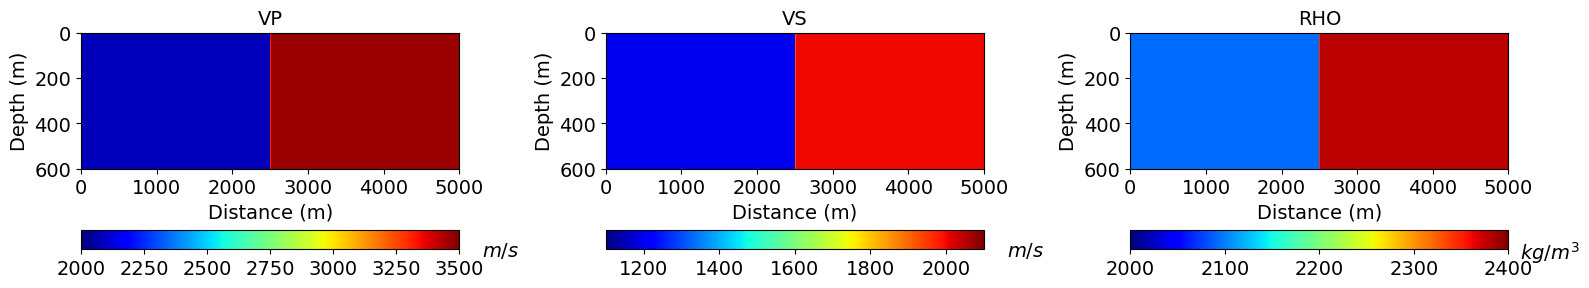

In [6]:
model_true.plot(aspect=3, cmap_range=cmap_range)

### Seismic Source 

In [7]:
# Create a seismic sources
source = Source(nt = nt, dt = dt, f0 = f0)

# Create wavelet
wvlt = wavelet(nt, dt, f0) * amp

for isrc in range(0, 5):
    source.add_source([500 + 300 * isrc, dx], wvlt, 'vz')

### Receiver

In [8]:
# Create a set of seismic receiver
geophone = Receiver(nt = nt, dt = dt)

for irec in range(40):
    geophone.add_receiver([2800 + 5 * dx * irec, dx], 'vz')


### Survey

In [9]:
survey = Survey(source=source, receiver=geophone, device='cpu')

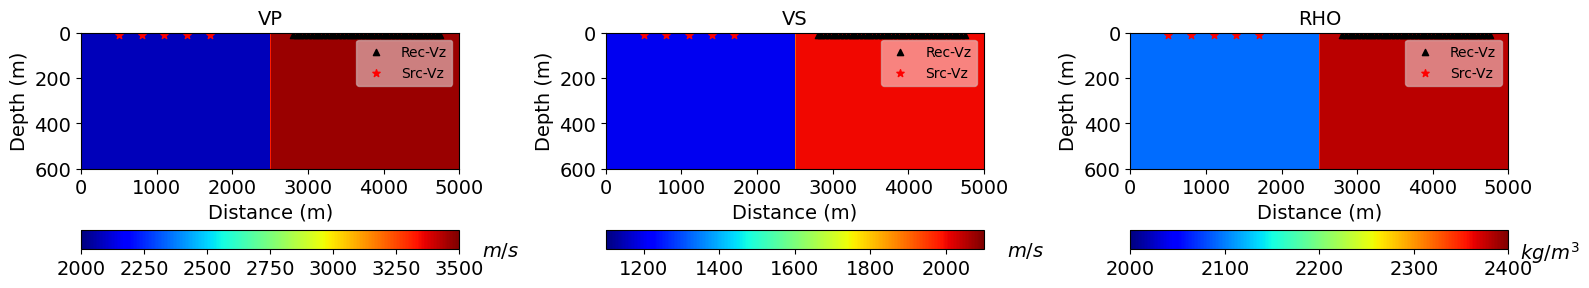

In [10]:
model_true.plot(survey, orientation='horizontal', aspect=3, cmap_range=cmap_range)

In [11]:
F = ElasticPropagator(model_true, survey)

Survey analysis completed: legal survey
free surface: True


In [12]:
data_true = F()

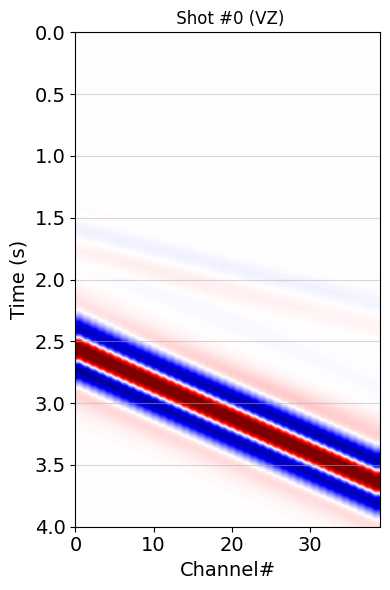

In [13]:
data_true.plot(comp='vz', clip=98, cmap='seismic', shotid=0)

In [14]:
data_obs = data_true.data['vz'].cpu().numpy()

# save the observed data, as if it is from ambient noise correlation
np.save('data_obs.npy', data_obs)

# The field data to use in imaging will be provided in the form of a 3D numpy array: (nsrc, nrec, nt)
print(data_obs.shape)


(5, 40, 4001)


## Transmitted Surface Wave Reverse Time Migration

### Part 1: Forward Wavefield Propagation

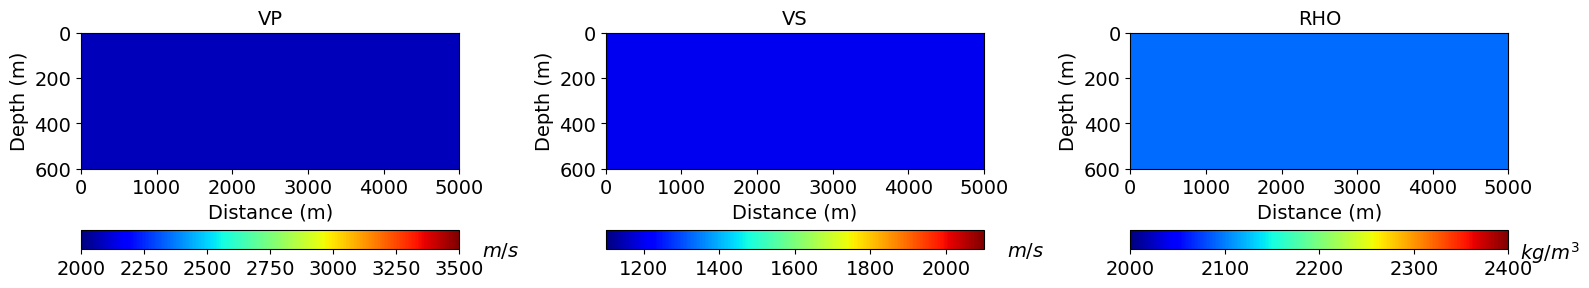

In [15]:
# 1. The migration velocity is obtained by "flooding" the source-side velocity all the way to the right of the model.
vs = np.ones((nz, nx), dtype=np.float32) * vs1
vp = vs * 1.732
rho = np.power(vp, 0.25) * 310

# Create a elastic model object
model_forward = ElasticModel(ox, oz, dx, dz, nx, nz, vp = vp, vs = vs,rho = rho, free_surface=True, nabc=20)
model_forward.plot(aspect=3, cmap_range=cmap_range)

In [16]:
# 2. The source are the same as those used as the one used to generate the observed data. But let's use one source for now

# Create a seismic sources
source_forward = Source(nt = nt, dt = dt, f0 = f0)

# Create wavelet
wvlt = wavelet(nt, dt, f0) * amp

isrc = 0
source_forward.add_source([500 + 300 * isrc, dx], wvlt, 'vz')
    
survey_forward = Survey(source=source_forward, receiver=geophone, device='cpu')

### The above setup means that we are propagating the source wavefield using the left side (source side) velocity model

In [17]:
F_forward = ElasticPropagator(model_forward, survey_forward)

# now the wavefield is saved in the forward modeling
data_forward = F_forward(save_wavefield=True)

Survey analysis completed: legal survey
free surface: True


In [18]:
## Extract the wavefield for Vx and Vz wavefield
wavefield_forward_vz = data_forward.data['wavefields_vz'].cpu().numpy().squeeze()

print(wavefield_forward_vz.shape)

(4001, 61, 501)


In [19]:
# plot the wavefield for vx
wavefield_ani = plot_wavefield(wavefield_forward_vz[::30, :, :])
HTML(wavefield_ani.to_jshtml())

### Part 2: Backward Wavefield Propagation

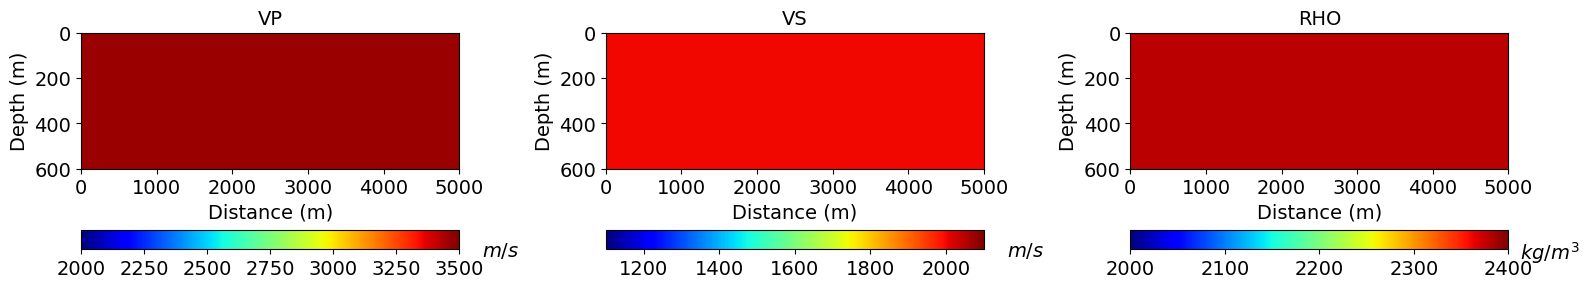

In [20]:
# 1. The migration velocity is obtained by "flooding" the receiver-side velocity all the way to the left of the model.
vs = np.ones((nz, nx), dtype=np.float32) * vs2
vp = vs * 1.732
rho = np.power(vp, 0.25) * 310

# Create a elastic model object
model_backward = ElasticModel(ox, oz, dx, dz, nx, nz, vp = vp, vs = vs,rho = rho, free_surface=True, nabc=20)
model_backward.plot(aspect=3, cmap_range=cmap_range)

In [21]:
# 2. Now, we need to set the receiver locations to be the same as the source locations used in the forward modeling. And the recorded data will be the wavelet. 

# load the observed data. This should be replaced by the data from the ambient noise correlation
sg = np.load('data_obs.npy')
print(sg.shape)

# since we are dealing the first source, use the first source data
sg = sg[0, :, :]
print(sg.shape)


# get receiver locations
rec_xz = survey.receiver.get_loc('vz')

# Create a seismic sources
source_backward = Source(nt = nt, dt = dt, f0 = f0)

for irec in range(rec_xz.shape[0]):
    rec_x = rec_xz[irec, 0]
    rec_z = rec_xz[irec, 1]

    # NOTE: the data is flipped in the time axis, the so-called "reverse time migration"
    source_backward.add_source([rec_x, rec_z], np.flip(sg[irec]), 'vz')
    
# Note: the geophone does not matter at all, all we need is the receiver backward wavefield
# the simutaneous must be set to True, to backward propagate the wavefield from all receivers together
survey_backward = Survey(source=source_backward, receiver=geophone, device='cpu', simultaneous=True)

(5, 40, 4001)
(40, 4001)


### The above setup means that we are propagating the receiver wavefield using the right side (receiver side) velocity model

In [22]:
F_backward = ElasticPropagator(model_backward, survey_backward)

# now the wavefield is saved in the forward modeling
data_backward = F_backward(save_wavefield=True)

Survey analysis completed: legal survey
free surface: True


In [23]:
## Extract the wavefield for Vx and Vz wavefield
wavefield_backward_vz = data_backward.data['wavefields_vz'].cpu().numpy().squeeze()

print(wavefield_backward_vz.shape)

(4001, 61, 501)


In [24]:
# plot the wavefield for vx
wavefield_ani = plot_wavefield(wavefield_backward_vz[::30, :, :])
HTML(wavefield_ani.to_jshtml())

### Part 3: Apply Imaging Condition

In [25]:
# rtm_image_vx = np.zeros((nz, nx))
rtm_image_vz = np.zeros((nz, nx))

wavefield_forward_vz = data_forward.data['wavefields_vz'].cpu().numpy().squeeze()
wavefield_backward_vz = data_backward.data['wavefields_vz'].cpu().numpy().squeeze()

# since we only use Z component for source and receiver, we only need to calculate the image for Vz
for it in range(nt):
    rtm_image_vz += wavefield_forward_vz[it] * wavefield_backward_vz[nt-it-1] 

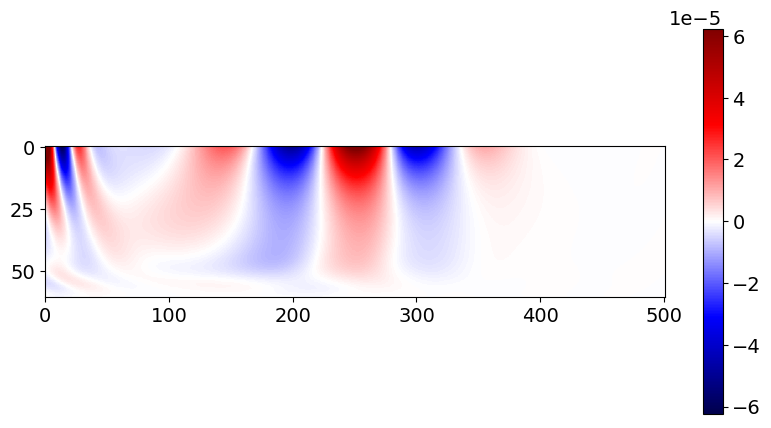

In [26]:
clip = np.percentile(rtm_image_vz, 99.9)
plt.figure(figsize=(10, 5))
plt.imshow(rtm_image_vz, aspect=2, cmap='seismic', vmin=-clip, vmax=clip)
plt.colorbar()
plt.show()

### Part 4: Post-process (not necessary, but something to consider)

In [27]:
# apply normalization along the depth, as surface wavefiled energy is much larger at shallow depth
rtm_image_vz_norm = np.zeros((nz, nx))
for iz in range(nz):
    rtm_image_vz_norm[iz] = rtm_image_vz[iz] / np.abs(rtm_image_vz[iz]).max()

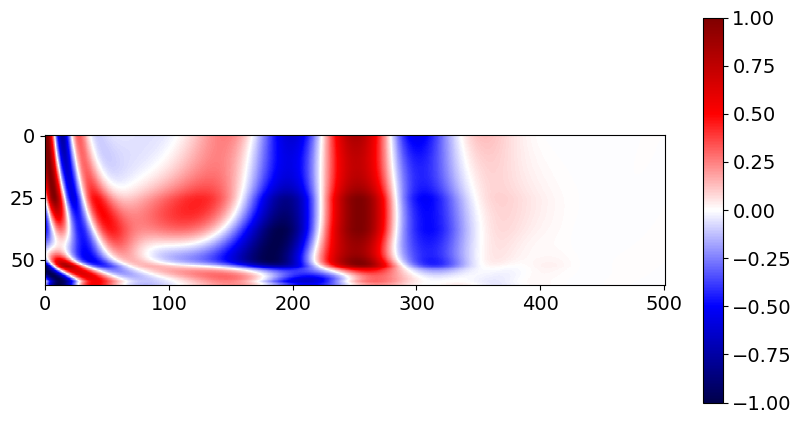

In [28]:
clip = np.percentile(rtm_image_vz_norm, 99.9)
plt.figure(figsize=(10, 5))
plt.imshow(rtm_image_vz_norm, aspect=2, cmap='seismic', vmin=-clip, vmax=clip)
plt.colorbar()
plt.show()

### Complete RTM workflow

The above steps from part 1 to part 3 showcased the separate steps of the RTM workflow. The complete RTM workflow is further provided below. 

Note: what is changed for each shots is the the source location, and the receiver data used for imaging. The velocity will remain the same.

In [29]:
# now we need to deal with all the sources
sg = np.load('data_obs.npy')
print(sg.shape)

(5, 40, 4001)


In [30]:
# Create a list of surveys for all sources for RTM. Please make sure the source locations are the same as those used in the modeling "observed data"
survey_forward_all  = []
survey_backward_all = []

for isrc in range(0, 5):
    
    ############### Forward survey
    source_forward = Source(nt = nt, dt = dt, f0 = f0)
    wvlt = wavelet(nt, dt, f0) * amp
    source_forward.add_source([500 + 300 * isrc, dx], wvlt, 'vz')
    survey_forward = Survey(source=source_forward, receiver=geophone, device='cpu')
    survey_forward_all.append(survey_forward)
    
    ############### Backward survey
    # get receiver locations
    rec_xz = survey.receiver.get_loc('vz')
    source_backward = Source(nt = nt, dt = dt, f0 = f0)

    for irec in range(rec_xz.shape[0]):
        rec_x = rec_xz[irec, 0]
        rec_z = rec_xz[irec, 1]

        # NOTE: the data is flipped in the time axis, the so-called "reverse time migration"
        source_backward.add_source([rec_x, rec_z], np.flip(sg[isrc, irec]), 'vz')
        
    # Note: the geophone does not matter at all, all we need is the receiver backward wavefield
    # the simutaneous must be set to True, to backward propagate the wavefield from all receivers together
    survey_backward = Survey(source=source_backward, receiver=geophone, device='cpu', simultaneous=True)
    survey_backward_all.append(survey_backward)
    
    print(f'Finished source {isrc+1} of {5} forward and backward survey')

Finished source 1 of 5 forward and backward survey
Finished source 2 of 5 forward and backward survey
Finished source 3 of 5 forward and backward survey
Finished source 4 of 5 forward and backward survey
Finished source 5 of 5 forward and backward survey


In [31]:
def migrate_shot(model_forward, model_backward, survey_forward_all, survey_backward_all):

    rtm_image_all = []

    for isrc in range(len(survey_forward_all)):
        
        print("Migrating source %d of %d" % (isrc+1, len(survey_forward_all)))        

        # Get the forward and backward survey
        survey_forward = survey_forward_all[isrc]
        survey_backward = survey_backward_all[isrc]

        # Forward modeling of source wavefield
        print("         Forward modeling...")
        F_forward = ElasticPropagator(model_forward, survey_forward)
        data_forward = F_forward(save_wavefield=True)

        # Backward modeling of receiver wavefield
        print("         Backward modeling...")
        F_backward = ElasticPropagator(model_backward, survey_backward)
        data_backward = F_backward(save_wavefield=True)

        # Apply imaging condition
        print("         Imaging condition...")
        rtm_image_vz = np.zeros((nz, nx))
        wavefield_forward_vz = data_forward.data['wavefields_vz'].cpu().numpy().squeeze()
        wavefield_backward_vz = data_backward.data['wavefields_vz'].cpu().numpy().squeeze()

        # It is the same as above imaging condition, but in a vectorized way
        rtm_image_vz = np.sum(
                wavefield_forward_vz * np.flip(wavefield_backward_vz, axis=0), axis=0
            )
        
        rtm_image_all.append(rtm_image_vz)
        
    rtm_image_all = np.array(rtm_image_all)
    
    return rtm_image_all

In [32]:
rtm_image_all = migrate_shot(model_forward, model_backward, survey_forward_all, survey_backward_all)

Migrating source 1 of 5
         Forward modeling...
Survey analysis completed: legal survey
free surface: True
         Backward modeling...
Survey analysis completed: legal survey
free surface: True
         Imaging condition...
Migrating source 2 of 5
         Forward modeling...
Survey analysis completed: legal survey
free surface: True
         Backward modeling...
Survey analysis completed: legal survey
free surface: True
         Imaging condition...
Migrating source 3 of 5
         Forward modeling...
Survey analysis completed: legal survey
free surface: True
         Backward modeling...
Survey analysis completed: legal survey
free surface: True
         Imaging condition...
Migrating source 4 of 5
         Forward modeling...
Survey analysis completed: legal survey
free surface: True
         Backward modeling...
Survey analysis completed: legal survey
free surface: True
         Imaging condition...
Migrating source 5 of 5
         Forward modeling...
Survey analysis complet

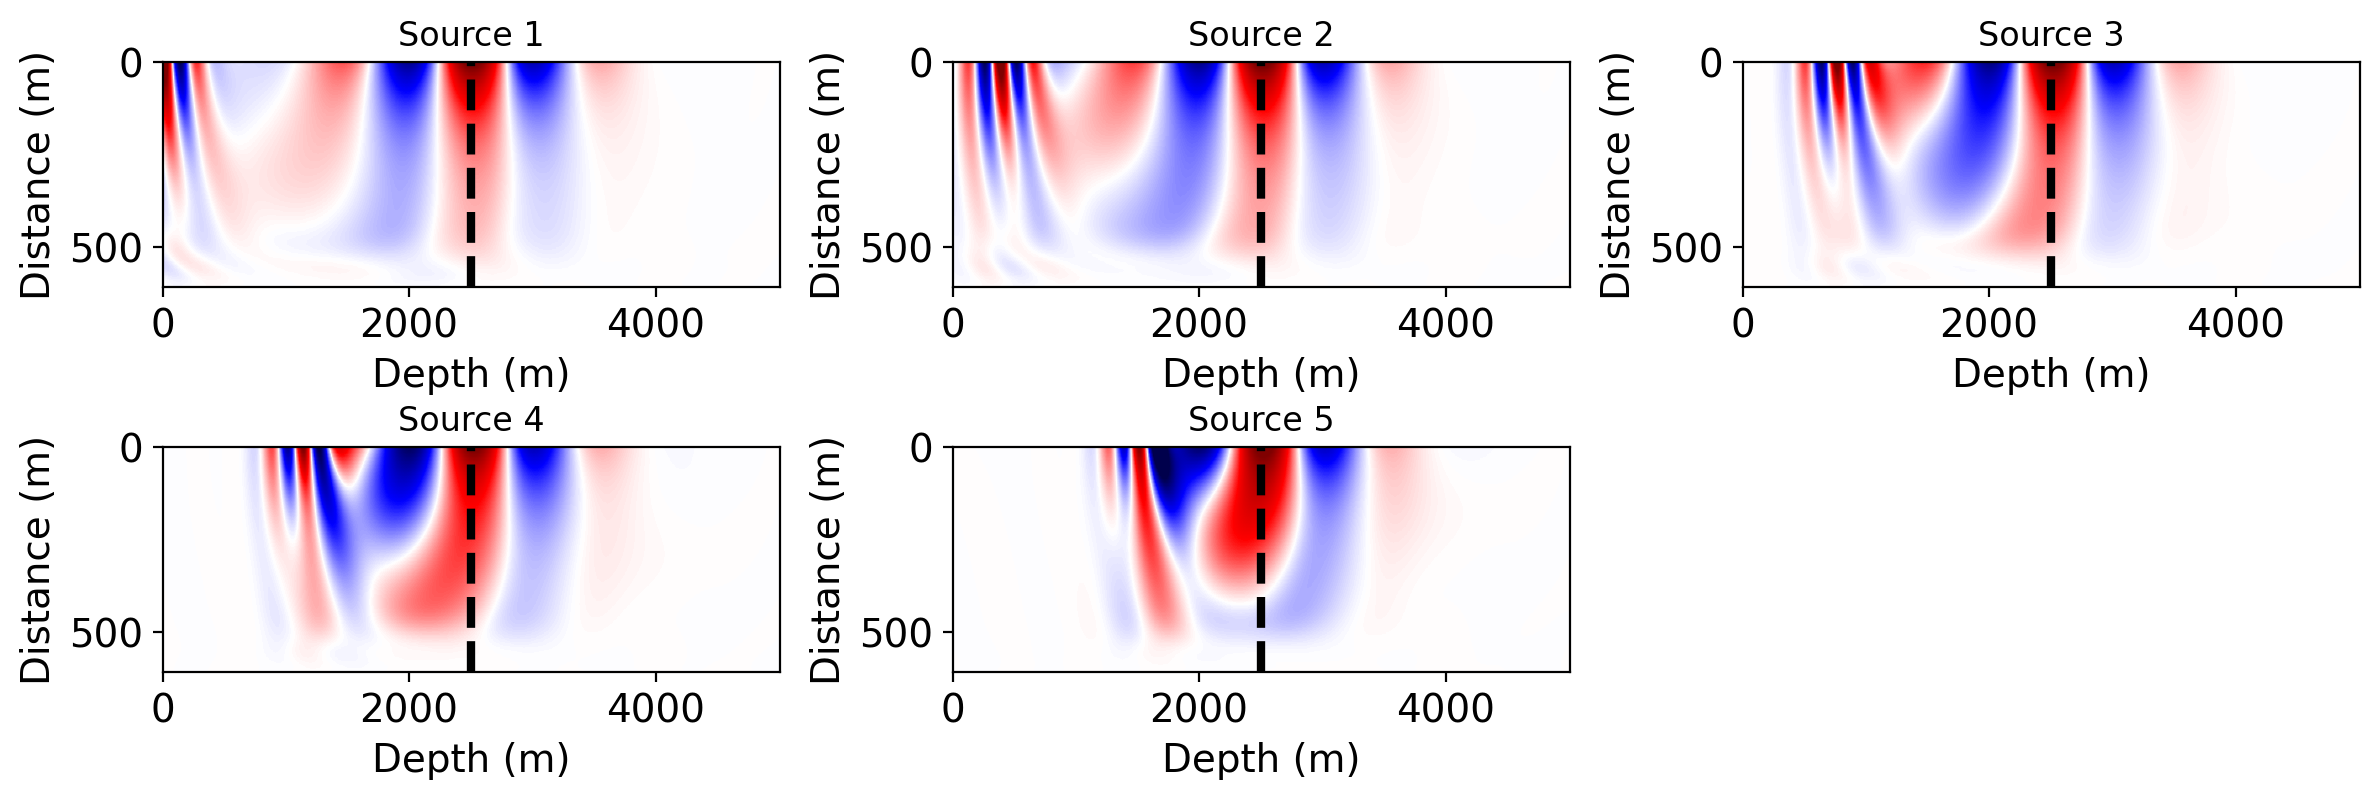

In [33]:
# plot the RTM image for all sources

extent = (0, nx*dx, nz*dz, 0)

clip = np.percentile(rtm_image_all, 99.9)

plt.figure(figsize=(12, 4), dpi=200)

for isrc in range(len(survey_forward_all)):
    plt.subplot(2, 3, isrc+1)
    plt.title(f'Source {isrc+1}')
    plt.imshow(rtm_image_all[isrc], aspect=3, cmap='seismic', vmin=-clip, vmax=clip, extent=extent)
    # plt.colorbar()
    plt.xlabel('Depth (m)')    
    plt.ylabel('Distance (m)')
    
    # plot the true location of the fault as dashed line
    plt.axvline(x=250*dx, color='k', linestyle='--', linewidth=3)
    
    
plt.tight_layout()
plt.show()


In [34]:
rtm_image_stack = np.mean(rtm_image_all, axis=0)

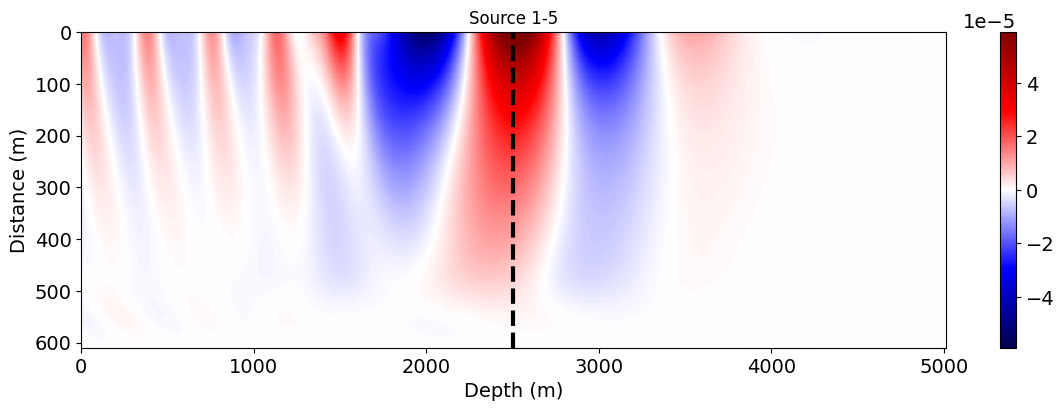

In [35]:
# plot the RTM image for all sources

extent = (0, nx*dx, nz*dz, 0)
clip = np.percentile(rtm_image_stack, 99.9)

plt.figure(figsize=(12, 4), dpi=100)
plt.imshow(rtm_image_stack, aspect=3, cmap='seismic', vmin=-clip, vmax=clip, extent=extent)
plt.colorbar()
plt.xlabel('Depth (m)')    
plt.ylabel('Distance (m)')
plt.title(f'Source 1-5')

# plot the true location of the fault as dashed line
plt.axvline(x=250*dx, color='k', linestyle='--', linewidth=3)


plt.tight_layout()
plt.show()


### Summary

The above steps are the complete RTM workflow. Here are some additional notes for the field data


1. A velocity model is needed, which can be from the surface wave inversion. Then, the migration velocity models for propagating the forward and backward wavefields are needed (or source and receiver velocity models, respectively).
2. The source wavelet is needed, which can be estimated from the field data. Aligning the ballistic waves and stack together is a way to estimate the source wavelet.
3. The field data is needed to store as the "data_obs.npy"
4. The sources and receivers should be suited at two sides of the fault, to have the trasmitted waves for imaging.

Another note is that there need to be obvious velocity contrast in the model, otherwise the imaging will not work well. Also, please consider the frequency content of the data, which determines the resolution of the imaging. The higher the frequency, the better the resolution. However, the higher the frequency, the more sensitive to shallower part. It is always helpful to think whether the best resolution can support the study of geological features.



## The end